# LangGraph Primer: Building Graph-Based AI Workflows

## Purpose

**LangGraph** is a powerful framework for building stateful, multi-step AI workflows as graphs. It is built on top of LangChain and uses LangChain’s core abstractions, such as LLMs, messages, and tools, while adding explicit control over execution flow and shared state.

In LangChain, workflows are often built as linear, step-by-step pipelines (chains). When more complex behavior is needed, such as branching, looping, retries, or parallel execution, developers typically add custom Python control logic around those steps. LangGraph extends this model by letting you describe how a workflow should run &mdash; its steps, decisions, and state &mdash; as a graph.

Workflows are modeled as graphs, where:

- **Nodes** are functions that do work (call LLMs, process data, execute tools)
- **Edges** define how execution flows between nodes
- **State** is a shared memory object that all nodes can read from and write to

This graph-based model provides fine-grained control over execution flow, making LangGraph well-suited for complex agent and orchestration patterns that are difficult to express using simple chains.

By the end of this primer, you will understand:

1. **Graph basics**: How to create a `StateGraph` with nodes and edges
2. **State as shared memory**: How all nodes access and update a common state object
3. **Conditional routing**: How to branch your workflow based on decisions
4. **Tool integration**: How to give your LLM access to tools using `bind_tools`
5. **Memory and persistence**: How to maintain conversation history across turns

Let's start simple and build up from there.

## Initial Setup

LangGraph is built on top of LangChain, so we’ll import components from LangChain’s core libraries, along with LangGraph itself:

- **`langgraph`**: The core library for building graph-based LLM workflows. It contains classes like `StateGraph` and constants like `START` and `END`.
- **`langchain_openai`**:  A library that wraps OpenAI models for use in `LangChain`, including the `ChatOpenAI` class.
- **`langchain_core`**: A library that defines LangChain’s core message types, such as `HumanMessage`, `AIMessage`, and `SystemMessage`.


The key primitives we will work with are:

| Primitive | Purpose |
|-----------|----------|
| `StateGraph` | The graph builder class |
| `START` | Special node marking the entry point |
| `END` | Special node marking the exit point |
| `add_node()` | Adds a function as a node |
| `add_edge()` | Connects two nodes |
| `compile()` | Builds the executable graph |

#### Run the Following Cell

In [1]:
# Core LangGraph Imports
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# LangChain Imports
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

# Python Standard Library
from typing import Literal
from typing_extensions import TypedDict, Annotated
import operator

# Display Utilities
from IPython.display import display, Markdown, Image

## Creating Your First Graph

Every LangGraph workflow starts with three things:

1. **State definition**: A `TypedDict` that defines the shared memory all nodes can access
2. **Node functions**: Python functions that read from state and return updates
3. **Graph structure**: Nodes connected by edges

Let's create the simplest possible graph: one that takes a user message and returns an LLM response.

**The State (Shared Memory)**

The state is the shared memory accessible to all nodes in the graph. Think of it as a whiteboard that every node can read from and write to. It is implemented as a class that defines the structure of the workflow’s shared memory. During execution, a state object (an instance of the class) stores the actual data that nodes read and update. In a chat application, it typically tracks the conversation history (for example, a `messages` list).

```python
class BasicState(TypedDict):
    messages: Annotated[list, operator.add] # conversation history; messages accumulate
```

**The Node Function**

A node is just a Python function that:
- Receives the current state object as input
- Calls the language model using the conversation history  
- Returns a dictionary containing updates that are merged into the state object

```python
def call_llm(state: BasicState):
    """Call the LLM with the current messages."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

```

**The Graph**

We build the graph by adding nodes and connecting them with edges:

```python
builder = StateGraph(BasicState)
builder.add_node("llm", call_llm)
builder.add_edge(START, "llm")
builder.add_edge("llm", END)
```

Let's see this in action.

#### Run the Following Cell

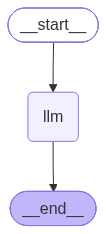

Graph compiled successfully!


In [4]:
# === Initialize the LLM ===
llm = ChatOpenAI(model="gpt-4.1")

# === Define the State ===
class BasicState(TypedDict):
    messages: Annotated[list, operator.add]  # conversation history; messages accumulate

# === Define the Node Function ===
def call_llm(state: BasicState):
    """Call the LLM with the current messages."""
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# === Build the Graph ===
builder = StateGraph(BasicState)
builder.add_node("llm", call_llm)
builder.add_edge(START, "llm")
builder.add_edge("llm", END)

# === Compile ===
simple_graph = builder.compile()

# === Visualize ===
display(Image(simple_graph.get_graph().draw_mermaid_png()))
print("Graph compiled successfully!")

#### Run the Following Cell

In [7]:
# === Test the Graph ===
result = simple_graph.invoke({
    "messages": [HumanMessage(content="What is the capital of France?")]
})

# === Display the Result ===
output = f"""
## Graph Execution Result

**User:** What is the capital of France?

**Assistant:** {result["messages"][-1].content}
"""
display(Markdown(output))


## Graph Execution Result

**User:** What is the capital of France?

**Assistant:** The capital of France is **Paris**.


### What Just Happened?

Let's break down the execution:

**1. State Definition With Annotated**

```python
messages: Annotated[list, operator.add]
```

The `Annotated[list, operator.add]` tells LangGraph how to combine state updates. When a node returns `{"messages": [response]}`, LangGraph **appends** to the existing messages rather than replacing them. This is crucial for building up conversation history.

**2. Graph Execution Flow**

```
START → llm → END
```

- The graph starts at `START`
- Flows to the `llm` node, which calls `call_llm(state)`
- The node reads from state (`state["messages"]`) and returns updates
- LangGraph merges these updates into the shared state
- The graph reaches `END` and returns the final state

**3. State as Shared Memory**

Every node receives the **full state** as input. When you return updates, LangGraph merges them back. This means:
- Nodes do not pass data directly to each other
- Instead, they read from and write to the shared state
- This makes it easy to add new nodes that need access to any part of the state

**Key Insight:** You are responsible for designing your state. Think carefully about what data needs to be shared across nodes.

## Conditional Routing: Branching Your Workflow

So far, our graph has a fixed path: `START → llm → END`. But what if we want different paths based on what happens during execution?

**Conditional edges** let you route to different nodes based on the current state. This is one of LangGraph's most powerful features.

**The Pattern**

```python
def routing_function(state: State) -> str:
    # Examine the state and decide where to go
    if some_condition:
        return "node_a"
    else:
        return "node_b"

builder.add_conditional_edges(
    "source_node",      # After this node...
    routing_function,   # ...call this function...
    {                   # ...and route based on the return value
        "node_a": "node_a",
        "node_b": "node_b"
    }
)
```

Let's see a simple example: routing customer messages to either a support agent or a sales agent based on the content.

#### Run the Following Cell

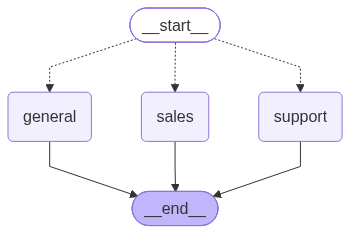

Router graph compiled!


In [8]:
# === Conditional Routing Example: Customer Service Router ===

# State includes the message and which department handled it
class RouterState(TypedDict):
    message: str
    department: str
    response: str

# === Routing Function ===
def route_message(state: RouterState) -> str:
    """Route based on message content."""
    message = state["message"].lower()
    
    # Simple keyword-based routing
    if any(word in message for word in ["buy", "price", "purchase", "cost", "deal"]):
        return "sales"
    elif any(word in message for word in ["help", "problem", "issue", "broken", "error"]):
        return "support"
    else:
        return "general"

# === Node Functions ===
def handle_sales(state: RouterState):
    """Sales department handler."""
    return {
        "department": "Sales",
        "response": f"Sales Team: Thanks for your interest! We'd love to help you with pricing. Your message: '{state['message']}'"
    }

def handle_support(state: RouterState):
    """Support department handler."""
    return {
        "department": "Support", 
        "response": f"Support Team: We're sorry to hear you're having issues. We'll help resolve this. Your message: '{state['message']}'"
    }

def handle_general(state: RouterState):
    """General inquiries handler."""
    return {
        "department": "General",
        "response": f"General Team: Thanks for reaching out! Your message: '{state['message']}'"
    }

# === Build the Graph ===
router_builder = StateGraph(RouterState)

# Add nodes
router_builder.add_node("sales", handle_sales)
router_builder.add_node("support", handle_support)
router_builder.add_node("general", handle_general)

# Conditional edge from START based on message content
router_builder.add_conditional_edges(
    START,
    route_message,
    {
        "sales": "sales",
        "support": "support",
        "general": "general"
    }
)

# All departments lead to END
router_builder.add_edge("sales", END)
router_builder.add_edge("support", END)
router_builder.add_edge("general", END)

# Compile
router_graph = router_builder.compile()

# Visualize
display(Image(router_graph.get_graph().draw_mermaid_png()))
print("Router graph compiled!")

#### Run the Following Cell

In [9]:
# === Test the Router ===

test_messages = [
    "I want to buy your product. What's the price?",
    "Help! My account is broken and I can't log in.",
    "Hello, I just wanted to say hi!"
]

for msg in test_messages:
    result = router_graph.invoke({"message": msg, "department": "", "response": ""})
    print(f"Message: \"{msg}\"")
    print(f"  → Routed to: {result['department']}")
    print(f"  → Response: {result['response']}")
    print()

Message: "I want to buy your product. What's the price?"
  → Routed to: Sales
  → Response: Sales Team: Thanks for your interest! We'd love to help you with pricing. Your message: 'I want to buy your product. What's the price?'

Message: "Help! My account is broken and I can't log in."
  → Routed to: Support
  → Response: Support Team: We're sorry to hear you're having issues. We'll help resolve this. Your message: 'Help! My account is broken and I can't log in.'

Message: "Hello, I just wanted to say hi!"
  → Routed to: General
  → Response: General Team: Thanks for reaching out! Your message: 'Hello, I just wanted to say hi!'



### What Just Happened?

The `route_message()` function examined the message content and returned a string indicating which node to visit:

```python
def route_message(state: RouterState) -> str:
    if "buy" in message or "price" in message:
        return "sales"      # → routes to sales node
    elif "help" in message or "problem" in message:
        return "support"    # → routes to support node
    else:
        return "general"    # → routes to general node
```

**Key Points:**

1. **Routing happens at edges, not nodes**: The routing function runs *between* nodes to decide where to go next

2. **Routing functions receive the full state**: You can make routing decisions based on any data in the state

3. **The mapping is explicit**: The dictionary `{"sales": "sales", "support": "support", ...}` maps return values to node names

This pattern is fundamental to LangGraph. You will see it again when we build tool-calling workflows, where we route based on whether the LLM requested a tool.

## Giving LLMs Access to Tools

Tools let your LLM take actions in the real world: searching the web, querying databases, calling APIs, and more.

In the code cell below, we will define two tools that the LLM can use: a weather lookup tool `get_weather` and a population lookup tool `get_population`.


**Defining Tools**

In LangGraph (via LangChain), you use the `@tool` decorator:

```python
from langchain_core.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"The weather in {city} is sunny, 72°F."
```

The **docstring** is critical. It tells the LLM what the tool does and when to use it.

**Binding Tools to the LLM**

To let the LLM use tools, we call `bind_tools()`:

```python
llm_with_tools = llm.bind_tools([get_weather])
```

Now when the LLM needs weather information, it can request a tool call instead of making something up.

**Handling Tool Calls**

When the LLM decides to use a tool, it returns an `AIMessage` with `tool_calls`. We need to:
1. Execute the requested tool
2. Return a `ToolMessage` with the result
3. Let the LLM continue with the tool's output

This creates a loop: LLM → Tool → LLM → (maybe more tools) → Final Response

We will use conditional routing to implement this loop.

#### Run the Following Cell

In [10]:
from langchain_core.tools import tool

# === Define Tools ===
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city.
    
    Use this tool when the user asks about weather conditions
    in a specific location.
    
    Args:
        city: The name of the city to get weather for.
    
    Returns:
        A string describing the current weather.
    """
    # Mock weather data
    weather_data = {
        "tokyo": "Sunny, 68°F (20°C), light breeze",
        "paris": "Cloudy, 59°F (15°C), chance of rain",
        "new york": "Clear, 75°F (24°C), humid",
        "london": "Overcast, 55°F (13°C), drizzle",
    }
    return weather_data.get(city.lower(), f"Weather data not available for {city}")

@tool
def get_population(city: str) -> str:
    """Get the population of a city.
    
    Use this tool when the user asks about how many people
    live in a specific city.
    
    Args:
        city: The name of the city.
    
    Returns:
        A string with population information.
    """
    population_data = {
        "tokyo": "approximately 14 million in the city, 37 million in the metro area",
        "paris": "approximately 2.1 million in the city, 12 million in the metro area",
        "new york": "approximately 8.3 million in the city, 20 million in the metro area",
        "london": "approximately 8.8 million in the city, 14 million in the metro area",
    }
    return population_data.get(city.lower(), f"Population data not available for {city}")

# === Create Tool List ===
tools = [get_weather, get_population]

# === Bind Tools to LLM ===
llm_with_tools = ChatOpenAI(model="gpt-4.1").bind_tools(tools)

print("Tools defined and bound to LLM:")
for t in tools:
    print(f"  - {t.name}: {t.description.split('.')[0]}")

Tools defined and bound to LLM:
  - get_weather: Get the current weather for a city
  - get_population: Get the population of a city


### Building a Tool-Calling Graph

Now we need to build a graph that can:
1. Call the LLM
2. Check if the LLM wants to use a tool
3. If yes, execute the tool and loop back
4. If no, finish and return the response

This requires **conditional routing**, which is one of LangGraph's most powerful features.

#### Run the Following Cell

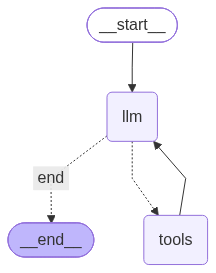

Tool-calling graph compiled!


In [11]:
# === Define State for Tool-Calling Graph ===
class ToolState(TypedDict):
    messages: Annotated[list, operator.add]

# === Create a tool lookup dictionary ===
tools_by_name = {t.name: t for t in tools}

# === Node: Call the LLM ===
def llm_node(state: ToolState):
    """Call the LLM with tools available."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# === Node: Execute Tools ===
def tool_node(state: ToolState):
    """Execute any tool calls from the LLM."""
    last_message = state["messages"][-1]
    tool_messages = []
    
    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        tool_messages.append(
            ToolMessage(content=result, tool_call_id=tool_call["id"])
        )
    
    return {"messages": tool_messages}

# === Routing Function ===
def should_continue(state: ToolState) -> str:
    """Decide whether to continue to tools or end."""
    last_message = state["messages"][-1]
    
    # If the LLM made tool calls, route to tools
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    
    # Otherwise, we're done
    return "end"

# === Build the Graph ===
tool_builder = StateGraph(ToolState)

# Add nodes
tool_builder.add_node("llm", llm_node)
tool_builder.add_node("tools", tool_node)

# Add edges
tool_builder.add_edge(START, "llm")

# Conditional edge: after LLM, either go to tools or end
tool_builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)

# After tools, always go back to LLM
tool_builder.add_edge("tools", "llm")

# Compile
tool_graph = tool_builder.compile()

# Visualize
display(Image(tool_graph.get_graph().draw_mermaid_png()))
print("Tool-calling graph compiled!")

### Testing the Tool-Calling Graph

Let's test with a question that requires using our weather tool.

#### Run the Following Cell

In [12]:
# === Test: Weather Query ===
result = tool_graph.invoke({
    "messages": [HumanMessage(content="What's the weather like in Tokyo?")]
})

# === Display Results ===
output = f"""
## Tool-Calling Graph Result

**User:** What's the weather like in Tokyo?

**Assistant:** {result["messages"][-1].content}

---

### Execution Trace

Let's see what messages were exchanged:
"""
display(Markdown(output))

for i, msg in enumerate(result["messages"]):
    msg_type = type(msg).__name__
    if msg_type == "HumanMessage":
        print(f"{i+1}. [Human] {msg.content}")
    elif msg_type == "AIMessage":
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            print(f"{i+1}. [AI] Tool call: {msg.tool_calls[0]['name']}({msg.tool_calls[0]['args']})")
        else:
            print(f"{i+1}. [AI] {msg.content}")
    elif msg_type == "ToolMessage":
        print(f"{i+1}. [Tool] {msg.content}")


## Tool-Calling Graph Result

**User:** What's the weather like in Tokyo?

**Assistant:** The weather in Tokyo is currently sunny, with a temperature of 68°F (20°C) and a light breeze.

---

### Execution Trace

Let's see what messages were exchanged:


1. [Human] What's the weather like in Tokyo?
2. [AI] Tool call: get_weather({'city': 'Tokyo'})
3. [Tool] Sunny, 68°F (20°C), light breeze
4. [AI] The weather in Tokyo is currently sunny, with a temperature of 68°F (20°C) and a light breeze.


#### Run the Following Cell

In [13]:
# === Test: Multi-Tool Query ===
result2 = tool_graph.invoke({
    "messages": [HumanMessage(content="What's the weather in Paris and how many people live there?")]
})

output = f"""
## Multi-Tool Query Result

**User:** What's the weather in Paris and how many people live there?

**Assistant:** {result2["messages"][-1].content}
"""
display(Markdown(output))

print("\n### Execution Trace")
for i, msg in enumerate(result2["messages"]):
    msg_type = type(msg).__name__
    if msg_type == "HumanMessage":
        print(f"{i+1}. [Human] {msg.content}")
    elif msg_type == "AIMessage":
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"{i+1}. [AI] Tool call: {tc['name']}({tc['args']})")
        else:
            content = msg.content
            print(f"{i+1}. [AI] {content}")
    elif msg_type == "ToolMessage":
        print(f"{i+1}. [Tool] {msg.content}")


## Multi-Tool Query Result

**User:** What's the weather in Paris and how many people live there?

**Assistant:** The current weather in Paris is cloudy with a temperature of about 59°F (15°C) and a chance of rain.

The population of Paris is approximately 2.1 million people in the city itself, and around 12 million in the metropolitan area.



### Execution Trace
1. [Human] What's the weather in Paris and how many people live there?
2. [AI] Tool call: get_weather({'city': 'Paris'})
2. [AI] Tool call: get_population({'city': 'Paris'})
3. [Tool] Cloudy, 59°F (15°C), chance of rain
4. [Tool] approximately 2.1 million in the city, 12 million in the metro area
5. [AI] The current weather in Paris is cloudy with a temperature of about 59°F (15°C) and a chance of rain.

The population of Paris is approximately 2.1 million people in the city itself, and around 12 million in the metropolitan area.


### What Just Happened?

Let's break down the tool-calling flow:

**1. Conditional Edges**

```python
tool_builder.add_conditional_edges(
    "llm",
    should_continue,
    {"tools": "tools", "end": END}
)
```

After the LLM node runs, LangGraph calls `should_continue(state)` to decide where to go next:
- If the LLM wants to use tools, return `"tools"` → go to tool node
- If the LLM is done, return `"end"` → go to END

**2. The Tool Call Loop**

```
START → llm → (tools?) → llm → (tools?) → ... → END
```

The LLM can call tools multiple times. Each time:
1. The LLM returns an `AIMessage` with `tool_calls`.
2. We route to the tool node.
3. The tool node executes each tool call.
4. The tool node returns one `ToolMessage` per tool call.
5. We route back to the LLM.
6. The LLM sees the tool results and continues.

**3. Parallel Tool Calls**

Notice in the second example, the LLM called both `get_weather` and `get_population` in a single turn. The tool node handles this by iterating over all tool calls.

**Note:** We built our `tool_node` function manually for learning purposes. In production, LangGraph provides a prebuilt `ToolNode` class that handles tool execution with additional features like error handling:

```python
from langgraph.prebuilt import ToolNode
tool_node = ToolNode(tools)
```

## Adding Memory With Checkpointers

So far, each time we invoke our graph, it starts fresh with no memory of previous conversations. For multi-turn conversations, we need **persistence**.

A **checkpointer** saves the state of your graph after each step. This enables:
- **Multi-turn conversations**: The graph remembers previous messages
- **Pause and resume**: You can stop and restart workflows
- **Debugging**: You can inspect state at any point in execution

**The Pattern**

```python
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# Each conversation needs a unique thread_id
config = {"configurable": {"thread_id": "user-123"}}

# First message
graph.invoke({"messages": [HumanMessage("Hi, I'm Alice")]}, config)

# Second message, same thread_id, graph remembers Alice
graph.invoke({"messages": [HumanMessage("What's my name?")]}, config)
```

Let's see this in action.

### First, Let's See the Problem &mdash; No Memory

#### Run the Following Cell

In [14]:
# === Without Memory ===
# Using our simple_graph from earlier (no checkpointer)

# First turn
result1 = simple_graph.invoke({
    "messages": [HumanMessage(content="Hi! My name is Alice.")]
})
print("Turn 1 - User: Hi! My name is Alice.")
print(f"Turn 1 - Assistant: {result1['messages'][-1].content}")

print("\n" + "="*50 + "\n")

# Second turn, new invocation, no memory
result2 = simple_graph.invoke({
    "messages": [HumanMessage(content="What's my name?")]
})
print("Turn 2 - User: What's my name?")
print(f"Turn 2 - Assistant: {result2['messages'][-1].content}")

Turn 1 - User: Hi! My name is Alice.
Turn 1 - Assistant: Hello, Alice! It’s nice to meet you. How can I help you today?


Turn 2 - User: What's my name?
Turn 2 - Assistant: You haven't told me your name yet! If you'd like to share it, feel free to let me know.


### The Problem: No Memory

Without a checkpointer, each invocation starts fresh. The graph has no idea that Alice introduced herself in the previous turn.

Now, let's add a checkpointer to fix this.

#### Run the Following Cell

In [15]:
# === With Memory ===

# Create checkpointer
checkpointer = InMemorySaver()

# Build a new graph with checkpointer
memory_builder = StateGraph(BasicState)
memory_builder.add_node("llm", call_llm)
memory_builder.add_edge(START, "llm")
memory_builder.add_edge("llm", END)

# Compile WITH checkpointer
memory_graph = memory_builder.compile(checkpointer=checkpointer)

# Define a thread_id for this conversation
config = {"configurable": {"thread_id": "alice-conversation"}}

# First turn
result1 = memory_graph.invoke(
    {"messages": [HumanMessage(content="Hi! My name is Alice.")]},
    config
)
print("Turn 1 - User: Hi! My name is Alice.")
print(f"Turn 1 - Assistant: {result1['messages'][-1].content}")

print("\n" + "="*50 + "\n")

# Second turn, same config, graph remembers!
result2 = memory_graph.invoke(
    {"messages": [HumanMessage(content="What's my name?")]},
    config
)
print("Turn 2 - User: What's my name?")
print(f"Turn 2 - Assistant: {result2['messages'][-1].content}")

Turn 1 - User: Hi! My name is Alice.
Turn 1 - Assistant: Hello, Alice! Nice to meet you. How can I help you today? 😊


Turn 2 - User: What's my name?
Turn 2 - Assistant: Your name is Alice!


### What Just Happened?

**1. The Checkpointer**

```python
checkpointer = InMemorySaver()
memory_graph = memory_builder.compile(checkpointer=checkpointer)
```

`InMemorySaver` stores graph state in memory. After each node executes, the state is saved.

**2. Thread IDs**

```python
config = {"configurable": {"thread_id": "alice-conversation"}}
```

The `thread_id` identifies this conversation. Different thread IDs = different conversation histories.

**3. State Accumulation**

When we invoke with the same `thread_id`:
- LangGraph loads the saved state, including previous messages
- Our new message is appended
- The LLM sees the full conversation history

**Production Note:** `InMemorySaver` is for development only. For production, use:
- `SqliteSaver` for local persistence
- `PostgresSaver` for database-backed persistence
- `RedisSaver` for distributed systems

#### Run the Following Cell

In [16]:
# === Different Thread IDs = Different Conversations ===

# Bob's conversation
bob_config = {"configurable": {"thread_id": "bob-conversation"}}
result_bob = memory_graph.invoke(
    {"messages": [HumanMessage(content="Hello! I'm Bob and I love pizza.")]},
    bob_config
)
print("Bob's Thread:")
print(f"  User: Hello! I'm Bob and I love pizza.")
print(f"  Assistant: {result_bob['messages'][-1].content}")

print("\n" + "="*50 + "\n")

# Back to Alice's conversation (uses saved state)
result_alice = memory_graph.invoke(
    {"messages": [HumanMessage(content="What was the first thing I told you?")]},
    config  # Alice's config from before
)
print("Alice's Thread (continued):")
print(f"  User: What was the first thing I told you?")
print(f"  Assistant: {result_alice['messages'][-1].content}")

print("\n" + "="*50 + "\n")

# Bob's conversation continues
result_bob2 = memory_graph.invoke(
    {"messages": [HumanMessage(content="What's my favorite food?")]},
    bob_config
)
print("Bob's Thread (continued):")
print(f"  User: What's my favorite food?")
print(f"  Assistant: {result_bob2['messages'][-1].content}")

Bob's Thread:
  User: Hello! I'm Bob and I love pizza.
  Assistant: Hello, Bob! 🍕 It’s great to meet a fellow pizza lover. What’s your favorite kind of pizza?


Alice's Thread (continued):
  User: What was the first thing I told you?
  Assistant: The first thing you told me was: "Hi! My name is Alice."


Bob's Thread (continued):
  User: What's my favorite food?
  Assistant: Your favorite food is pizza! You mentioned it in your first message. 🍕


Each `thread_id` maintains its own conversation history. Alice's conversation knows her name, Bob's conversation knows about pizza, and they never mix.

This is how you would support multiple users in a production application: Each user gets their own `thread_id`, and their conversations are completely isolated.

## Complete Example: Travel Assistant With Tools and Memory

Let's put everything together: a travel assistant that can look up weather and population data, and remembers the conversation.

This combines:
- **State management** with `TypedDict`
- **Tool calling** with `bind_tools` and conditional routing
- **Memory** with `InMemorySaver`

#### Run the Following Cell

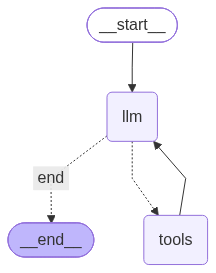

Travel assistant ready!


In [17]:
# === Complete Travel Assistant ===

# State
class TravelState(TypedDict):
    messages: Annotated[list, operator.add]

# LLM with tools
travel_llm = ChatOpenAI(model="gpt-4.1").bind_tools(tools)

# Nodes
def travel_llm_node(state: TravelState):
    # Add system message for context
    messages = [
        SystemMessage(content="You are a helpful travel assistant. You can look up weather and population information for cities. Be friendly and conversational.")
    ] + state["messages"]
    response = travel_llm.invoke(messages)
    return {"messages": [response]}

def travel_tool_node(state: TravelState):
    last_message = state["messages"][-1]
    tool_messages = []
    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        tool_messages.append(
            ToolMessage(content=result, tool_call_id=tool_call["id"])
        )
    return {"messages": tool_messages}

def travel_should_continue(state: TravelState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"

# Build graph
travel_builder = StateGraph(TravelState)
travel_builder.add_node("llm", travel_llm_node)
travel_builder.add_node("tools", travel_tool_node)
travel_builder.add_edge(START, "llm")
travel_builder.add_conditional_edges(
    "llm",
    travel_should_continue,
    {"tools": "tools", "end": END}
)
travel_builder.add_edge("tools", "llm")

# Compile with memory
travel_checkpointer = InMemorySaver()
travel_assistant = travel_builder.compile(checkpointer=travel_checkpointer)

display(Image(travel_assistant.get_graph().draw_mermaid_png()))
print("Travel assistant ready!")

#### Run the Following Cell

In [18]:
# === Multi-Turn Conversation ===

travel_config = {"configurable": {"thread_id": "trip-planning"}}

# Turn 1: Introduction
r1 = travel_assistant.invoke(
    {"messages": [HumanMessage(content="Hi! I'm planning a trip to Tokyo.")]},
    travel_config
)
print("User: Hi! I'm planning a trip to Tokyo.")
print(f"Assistant: {r1['messages'][-1].content}")
print("\n" + "-"*50 + "\n")

# Turn 2: Ask about weather
r2 = travel_assistant.invoke(
    {"messages": [HumanMessage(content="What's the weather like there?")]},
    travel_config
)
print("User: What's the weather like there?")
print(f"Assistant: {r2['messages'][-1].content}")
print("\n" + "-"*50 + "\n")

# Turn 3: Ask about population (uses memory to know we're talking about Tokyo)
r3 = travel_assistant.invoke(
    {"messages": [HumanMessage(content="How crowded is it? How many people live there?")]},
    travel_config
)
print("User: How crowded is it? How many people live there?")
print(f"Assistant: {r3['messages'][-1].content}")
print("\n" + "-"*50 + "\n")

# Turn 4: Reference earlier context
r4 = travel_assistant.invoke(
    {"messages": [HumanMessage(content="Based on everything you've told me, is this a good time to visit?")]},
    travel_config
)
print("User: Based on everything you've told me, is this a good time to visit?")
print(f"Assistant: {r4['messages'][-1].content}")

User: Hi! I'm planning a trip to Tokyo.
Assistant: That sounds exciting! Tokyo is a vibrant city with a fantastic mix of traditional culture and modern attractions. Do you already have some plans for what you’d like to see and do there, or would you like some recommendations? Also, would you like to know about the current weather or any other information to help with your planning?

--------------------------------------------------

User: What's the weather like there?
Assistant: Right now, the weather in Tokyo is sunny with a comfortable temperature of 68°F (20°C) and a light breeze. It’s a great time to explore the city, whether you’re sightseeing, walking in parks, or enjoying outdoor markets!

If there’s anything specific you’re planning—like a day trip or visiting certain attractions—I can help you check more detailed forecasts or suggest activities that match the weather. Just let me know!

--------------------------------------------------

User: How crowded is it? How many peo

### What Just Happened?

The travel assistant demonstrated all the core LangGraph concepts working together:

**1. Stateful Conversation**

The assistant remembered that we were talking about Tokyo, even when we just said "there" or "it". The checkpointer saved the full conversation history.

**2. Automatic Tool Selection**

When asked about weather, the LLM decided to call `get_weather`. When asked about population, it called `get_population`. We did not hard-code any routing logic for this.

**3. Context-Aware Responses**

In the final turn, the assistant synthesized information from the entire conversation to give a recommendation. This required both the tool results **and** the conversation memory.

**4. The Graph Structure**

```
START → llm → (conditional) → tools → llm → ... → END
```

The conditional edge after `llm` checks for tool calls. If found, it routes to `tools`, which executes them and returns to `llm`. This loop continues until the LLM produces a final response without tool calls.

## Summary: What You've Learned

You have now learned the fundamentals of LangGraph.

**Key Takeaways:**

1. **State is shared memory**: All nodes read from and write to a common state object. You design this state using `TypedDict`.

2. **Nodes are just functions**: Any Python function that takes state and returns updates can be a node. This makes LangGraph very flexible.

3. **Edges control flow**: Regular edges for fixed paths, conditional edges for dynamic routing based on state.

4. **Conditional routing is powerful**: You can branch, loop, and create complex workflows by examining state and deciding where to go next.

5. **Tools work through the agentic loop**: LLM decides to use a tool → tool executes → result goes back to LLM → repeat until done.

6. **Memory requires checkpointers**: Use `InMemorySaver` for development, database-backed savers (`PostgresSaver`, `SqliteSaver`) for production.

7. **Visualization helps debugging**: Always use `graph.get_graph().draw_mermaid_png()` to visualize your graph structure.

In this course, you will use LangGraph to implement various agentic patterns like parallelization, orchestrator workflows, and evaluator-optimizer loops.